In [9]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('vader_lexicon')
import os
from dotenv import load_dotenv
from mistralai.client import Mistral
load_dotenv()
client = Mistral(api_key=os.environ["MISTRAL_API_KEY"])
from typing import TypedDict, Literal

class ReviewState(TypedDict):
    text: str
    sentiment: str
    response: str

def route_sentiment(state: ReviewState)->Literal['positive_res', 'run_diagnosis']:
    analyzer = SentimentIntensityAnalyzer()
    score = analyzer.polarity_scores(state['text'])
    if score['compound']>0: 
        return 'positive_res'
    else:
        return 'run_diagnosis'



def run_diagnosis(state: ReviewState) -> ReviewState:
    messages = [
    {"role": "user", "content": state['text']}
    ]
    response = client.chat.complete(
        model="mistral-medium-latest",
        messages=messages
    )
    state['response']=  response
    return state

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\KUNAL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [10]:
def get_sentiment(state: ReviewState)->ReviewState:
    return state

def positive_res(state: ReviewState)->ReviewState:
    state['response']= 'Hi! Thankyou for your response, We hope to see you again soon.'
    return state

def negative_res(state: ReviewState)->ReviewState:
    return state

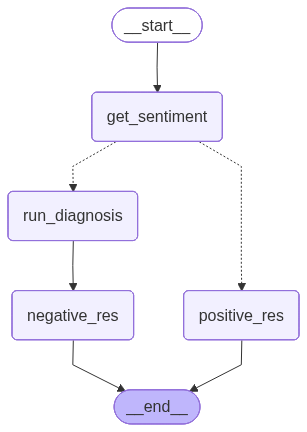

In [11]:
from langgraph.graph import START, END, StateGraph

graph= StateGraph(ReviewState)
graph.add_node('get_sentiment', get_sentiment)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('positive_res', positive_res)
graph.add_node('negative_res', negative_res)


graph.add_edge(START, 'get_sentiment')
graph.add_conditional_edges('get_sentiment', route_sentiment)
graph.add_edge('positive_res', END)
graph.add_edge('run_diagnosis','negative_res')
graph.add_edge('negative_res', END)

workflow = graph.compile()

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())


In [14]:
init_st= {'text': 'shittyass product i hate it'}
res=workflow.invoke(init_st)

In [ ]:
res['response']

ChatCompletionResponse(id='e9a45d2491c740a5aa06eb2b4a998f15', object='chat.completion', model='mistral-medium-latest', usage=UsageInfo(prompt_tokens=10, completion_tokens=132, total_tokens=142, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}), created=1778739072, choices=[ChatCompletionChoice(index=0, finish_reason='stop', message=AssistantMessage(role='assistant', content='I’m sorry to hear you’re frustrated—it sounds like whatever you’re dealing with is really not meeting your expectations. If you’d like, I can help you:\n\n- **Troubleshoot the issue** (if it’s tech-related)\n- **Find alternatives** (if the product is truly bad)\n- **Guide you on returns/refunds** (if applicable)\n- **Just vent** (sometimes that’s all you need!)\n\nWhat’s the product, and what’s making it so awful? I’m happy to help however I can. 💀🔥 (Or just scream into the void with you—your call.)', tool_calls=None, prefix=False), messages=None)])

In [28]:
print(res['response'].choices[0].message.content)

I’m sorry to hear you’re frustrated—it sounds like whatever you’re dealing with is really not meeting your expectations. If you’d like, I can help you:

- **Troubleshoot the issue** (if it’s tech-related)
- **Find alternatives** (if the product is truly bad)
- **Guide you on returns/refunds** (if applicable)
- **Just vent** (sometimes that’s all you need!)

What’s the product, and what’s making it so awful? I’m happy to help however I can. 💀🔥 (Or just scream into the void with you—your call.)
